In [14]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Using this magic command, we turn on auto-reloading for libraries imported by %aimport
%load_ext autoreload
%autoreload 2

%aimport FullModel
%aimport DataPreparation

In [30]:
# Microgrids data
from DataPreparation import getMGData, getCEMSData
N = 3
T = 12
mg_private, mg_public = {}, {}
for mg_id in range(N):
    mg_private[mg_id], mg_public[mg_id] = getMGData(N, mg_id, T)
cems = getCEMSData(N, T, mg_public, mg_private)

In [ ]:
from FullInfo import FullModel
full_model = FullModel(mg_private, cems)
full_model.model.optimize()
full_model.objective.getValue()

Set parameter OutputFlag to value 1
Set parameter Threads to value 3
Set parameter TimeLimit to value 120
Set parameter MIPGap to value 0.001
Set parameter NumericFocus to value 2
Set parameter FeasibilityTol to value 0.001
Set parameter Cuts to value 2
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 3 threads

Non-default parameters:
TimeLimit  120
FeasibilityTol  0.001
MIPGap  0.001
Cuts  2
NumericFocus  2
Threads  3

Optimize a model with 1761 rows, 1251 columns and 5817 nonzeros
Model fingerprint: 0xaf60f2d5
Variable types: 1215 continuous, 36 integer (36 binary)
Coefficient statistics:
  Matrix range     [1e-04, 1e+02]
  Objective range  [5e-02, 4e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [7e-01, 1e+03]
Found heuristic solution: objective 0.1237377
Presolve removed 1259 rows and 49

array(0.59355126)

In [29]:
full_model.eta_r.x

array([0.51049708, 0.7853653 , 0.52282582])

In [21]:
name = f'FullModel_tau({full_model.configs[0].tau})_'

array([[  0.       ,   0.       ,   0.       ,   0.       ],
       [  0.       ,  58.1445941,   0.       ,   0.       ],
       [113.8565706,  50.3171619,   0.       ,   0.       ]])

In [114]:
# Cost table
indices = [f'Community {i}' for i in range(n_mgs)] + ['System']
table = {key: np.zeros(n_mgs) for key in [
    'Cost Before Trade ($)',
    'Utility Fee ($)',
    'Payments ($)',
    'Utility Subsidy Usage ($)',
    'Purchase Subsidy Usage ($)',
    'Net Cost After Trade']}
table['Cost Before Trade ($)'] = full_model.C_t_Non
table['Utility Fee ($)'] = full_model.C_u.x
table['Payments ($)'] = full_model.C_e.x
table['Utility Subsidy Usage ($)'] = [full_model.configs[i].usrr *
                                      (full_model.e_buy.x[i].sum() +
                                      full_model.e_sell.x[i].sum()) for i in range(n_mgs)]
table['Purchase Subsidy Usage ($)'] = [full_model.configs[i].fsrr *
                                      full_model.pi_buy.x[i].sum() for i in range(n_mgs)]
table['Net Cost After Trade'] = full_model.C_t.x
table = {key: np.append(val, np.sum(val)) for key, val in table.items()}
pd.DataFrame(table, index=indices).to_csv(f'Results/{name}cost_table.csv')

In [115]:
table = {key: np.zeros(n_mgs) for key in ['Resilience Before Trade',
                                          'Cost Before Trade',
                                          'Resilience After Trade',
                                          'Cost After Trade']}
table['Resilience Before Trade'] = full_model.eta_r_Non
table['Resilience After Trade'] = full_model.eta_r.x
table['Cost Before Trade'] = full_model.eta_c_Non
table['Cost After Trade'] = full_model.eta_c.x
# adding system wide
table = {key: np.append(val, np.average(val)) for key, val in table.items()}
pd.DataFrame(table, index=indices).to_csv(f'Results/{name}metric_table.csv')

In [116]:
table = {key: np.zeros(n_mgs) for key in ['Generation', 'Average Load', 'Buying', 'Selling']}
probs = full_model.configs[0].probs

generation = [np.average(full_model.g_dg[i].x.sum(axis=1) + full_model.g_pv[i].x.sum(axis=1),
                         weights=probs) for i in range(n_mgs)]
avg_load = [np.average(full_model.configs[i].load.sum(axis=1),
                       weights=probs) for i in range(n_mgs)]
total_buy = [full_model.e_buy.x[i].sum() for i in range(n_mgs)]
total_sell = [full_model.e_sell.x[i].sum() for i in range(n_mgs)]
table['Generation'] = generation
table['Average Load'] = avg_load
table['Buying'] = total_buy
table['Selling'] = total_sell
table = {key: np.append(val, np.sum(val)) for key, val in table.items()}
pd.DataFrame(table, index=indices).to_csv(f'Results/{name}power_table.csv')

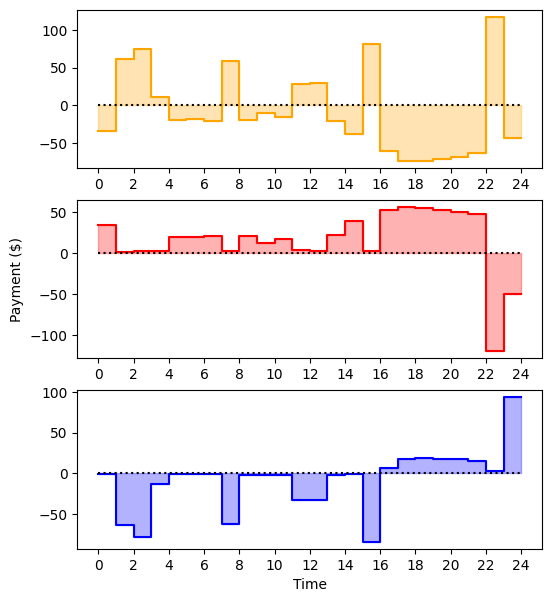

In [137]:
buy = np.stack([full_model.pi_buy.x[i].sum(axis=0) for i in range(n_mgs)])
sell = np.stack([full_model.pi_sell.x[i].sum(axis=0) for i in range(n_mgs)])
buy_sell = buy - sell
buy_sell = np.concatenate((buy_sell, buy_sell[:, -1][:, np.newaxis]), axis=1)

fig, axs = plt.subplots(3, 1, figsize=(6, 7))
x = range(25)
y = buy_sell
axs[0].step(x, y[0], where='post', color='orange', label='MG 1')
axs[0].fill_between(x, y[0], step='post', alpha=0.3, color='orange')

axs[1].step(x, y[1], where='post', color='red', label='MG 2')
axs[1].fill_between(x, y[1], step='post', alpha=0.3, color='red')

axs[2].step(x, y[2], where='post', color='blue', label='MG 3')
axs[2].fill_between(x, y[2], step='post', alpha=0.3, color='blue')

for ax in axs:
    ax.set_xticks(np.linspace(0, 24, 13))
    ax.plot([0, 24], [0, 0], ':', color='black')
plt.xlabel('Time')
axs[1].set_ylabel('Payment ($)')

plt.savefig(f'Figures/{name}price.jpg', bbox_inches='tight', dpi=600)


In [127]:
sell.shape

(3, 24)